In [1]:
import tensorflow as tf
import numpy as np
import os

IMG_DIR = "../../quadratic_dataset/images"
CURVE_DIR = "../../quadratic_dataset/curve_points"

def load_sample(row):

    # -----------------------------
    # Load image
    # -----------------------------

    img_path = os.path.join(
        IMG_DIR,
        row["filename"]
    )

    img = tf.io.read_file(img_path)
    img = tf.image.decode_png(img, channels=3)
    img = tf.image.resize(img, (224, 224))
    img = tf.cast(img, tf.float32) / 255.0

    # -----------------------------
    # Load curve points
    # -----------------------------

    curve_path = os.path.join(
        CURVE_DIR,
        row["filename"].replace(".png", ".npy")
    )

    curve_points = np.load(curve_path).astype(np.float32)

    # -----------------------------
    # Return
    # -----------------------------

    return img, curve_points

In [2]:
import tensorflow as tf
from tensorflow.keras import layers, Model

inputs = layers.Input(shape=(224, 224, 3))

x = inputs

# --- shared CNN backbone ---
for filters in [8, 16, 32, 64, 128]:
    x = layers.Conv2D(filters, 3, padding="same", activation="relu")(x)
    x = layers.Conv2D(filters, 3, padding="same", activation="relu")(x)
    x = layers.MaxPooling2D(2)(x)

# Aggregate spatial information without exploding parameter count
x = layers.GlobalAveragePooling2D()(x)

# Small intermediate dense layer for more stable regression
x = layers.Dense(128, activation="relu")(x)

# --- output head: 6 quadratic coefficients ---
coeffs = layers.Dense(6, activation="linear")(x)
coeffs = layers.Lambda(
    lambda t: tf.nn.l2_normalize(t, axis=-1)
)(coeffs)

model = Model(inputs=inputs, outputs=coeffs)

In [3]:
import tensorflow as tf

def geometric_loss(curve_points, pred_coeffs, eps=1e-6):
    """
    curve_points : Tensor of shape (batch_size, N_points, 2)
                   Normalized curve points (x, y)

    pred_coeffs : Tensor of shape (batch_size, 6)
                  Predicted quadratic coefficients
                  [a, b, c, d, e, f]

    returns:
        scalar loss
    """

    # ---------------------------------------
    # Unpack coordinates
    # ---------------------------------------

    x = curve_points[..., 0]
    y = curve_points[..., 1]

    # ---------------------------------------
    # Unpack coefficients
    # ---------------------------------------

    a = pred_coeffs[:, 0:1]
    b = pred_coeffs[:, 1:2]
    c = pred_coeffs[:, 2:3]
    d = pred_coeffs[:, 3:4]
    e = pred_coeffs[:, 4:5]
    f = pred_coeffs[:, 5:6]

    # ---------------------------------------
    # Evaluate implicit polynomial
    # ---------------------------------------

    F = (
        a * x**2 +
        b * x * y +
        c * y**2 +
        d * x +
        e * y +
        f
    )

    # ---------------------------------------
    # Analytical gradients
    # ---------------------------------------

    Fx = 2.0 * a * x + b * y + d
    Fy = b * x + 2.0 * c * y + e

    grad_norm = tf.sqrt(Fx**2 + Fy**2 + eps)

    # ---------------------------------------
    # Approximate geometric distance
    # ---------------------------------------

    distance = tf.abs(F) / grad_norm

    return tf.reduce_mean(distance)

In [4]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss=geometric_loss
)

In [5]:
import pandas as pd

df = pd.read_csv("../../quadratic_dataset/labels.csv")

In [6]:
def dataset_from_dataframe(df, batch_size=16, shuffle=True):

    def gen():
        for _, row in df.iterrows():
            yield load_sample(row)

    ds = tf.data.Dataset.from_generator(
        gen,
        output_signature=(
            tf.TensorSpec(
                shape=(224, 224, 3),
                dtype=tf.float32
            ),
            tf.TensorSpec(
                shape=(256, 2),
                dtype=tf.float32
            )
        )
    )

    # Shuffle the entire dataset if requested
    if shuffle:
        ds = ds.shuffle(len(df))

    # Create batches and enable asynchronous prefetching
    ds = ds.batch(batch_size)
    ds = ds.prefetch(tf.data.AUTOTUNE)

    return ds

In [7]:
from sklearn.model_selection import train_test_split

# Split the dataset into training and validation sets
train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42
)

# Reset indices after splitting for clean iteration
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

# Create TensorFlow datasets
train_ds = dataset_from_dataframe(train_df, batch_size=16, shuffle=True)
val_ds = dataset_from_dataframe(val_df, batch_size=16, shuffle=False)

In [8]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=8,
        restore_best_weights=True
    )
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=100,
    callbacks=callbacks
)

Epoch 1/100
    250/Unknown 53s 184ms/step - loss: 0.2263

2026-06-22 16:34:51.447565: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]
/Users/aysegul/miniconda3/envs/customerenv/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


250/250 ━━━━━━━━━━━━━━━━━━━━ 56s 196ms/step - loss: 0.1733 - val_loss: 0.1503
Epoch 2/100


2026-06-22 16:34:54.445889: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]


250/250 ━━━━━━━━━━━━━━━━━━━━ 54s 196ms/step - loss: 0.1509 - val_loss: 0.1498
Epoch 3/100


...

250/250 ━━━━━━━━━━━━━━━━━━━━ 54s 195ms/step - loss: 0.0956 - val_loss: 0.0946
Epoch 18/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 54s 196ms/step - loss: 0.0991 - val_loss: 0.0932
Epoch 19/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 56s 203ms/step - loss: 0.0902 - val_loss: 0.0954
Epoch 20/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 55s 200ms/step - loss: 0.0968 - val_loss: 0.0945
Epoch 21/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 56s 204ms/step - loss: 0.0956 - val_loss: 0.0907
Epoch 22/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 55s 200ms/step - loss: 0.0932 - val_loss: 0.0866
Epoch 23/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 54s 194ms/step - loss: 0.0859 - val_loss: 0.0931
Epoch 24/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 57s 208ms/step - loss: 0.0904 - val_loss: 0.0873
Epoch 25/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 56s 203ms/step - loss: 0.0819 - val_loss: 0.0822
Epoch 26/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 58s 210ms/step - loss: 0.0982 - val_loss: 0.1009
Epoch 27/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 60s 219ms/step - loss: 0.0898 - val_loss: 0.0850
Epoch 28/100

2026-06-22 17:03:22.465276: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]


250/250 ━━━━━━━━━━━━━━━━━━━━ 54s 196ms/step - loss: 0.0776 - val_loss: 0.0771
Epoch 34/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 55s 202ms/step - loss: 0.1374 - val_loss: 0.1384
Epoch 35/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 56s 204ms/step - loss: 0.1060 - val_loss: 0.0963
Epoch 36/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 56s 206ms/step - loss: 0.0835 - val_loss: 0.0774
Epoch 37/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 59s 212ms/step - loss: 0.0841 - val_loss: 0.0800
Epoch 38/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 56s 204ms/step - loss: 0.0767 - val_loss: 0.0769
Epoch 39/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 57s 209ms/step - loss: 0.0733 - val_loss: 0.0753
Epoch 40/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 59s 214ms/step - loss: 0.0713 - val_loss: 0.0727
Epoch 41/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 60s 216ms/step - loss: 0.0729 - val_loss: 0.0742
Epoch 42/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 55s 198ms/step - loss: 0.0706 - val_loss: 0.0772
Epoch 43/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 54s 197ms/step - loss: 0.0704 - val_loss: 0.0697
Epoch 44/100

2026-06-22 17:32:42.858819: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]


250/250 ━━━━━━━━━━━━━━━━━━━━ 54s 195ms/step - loss: 0.0733 - val_loss: 0.0684
Epoch 66/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 54s 195ms/step - loss: 0.0602 - val_loss: 0.0655
Epoch 67/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 54s 198ms/step - loss: 0.0572 - val_loss: 0.0605
Epoch 68/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 54s 196ms/step - loss: 0.0568 - val_loss: 0.0636
Epoch 69/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 55s 199ms/step - loss: 0.0652 - val_loss: 0.0598
Epoch 70/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 55s 198ms/step - loss: 0.0587 - val_loss: 0.0610
Epoch 71/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 54s 195ms/step - loss: 0.0560 - val_loss: 0.0615
Epoch 72/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 54s 197ms/step - loss: 0.0592 - val_loss: 0.0591
Epoch 73/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 54s 196ms/step - loss: 0.0542 - val_loss: 0.0631
Epoch 74/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 54s 195ms/step - loss: 0.0534 - val_loss: 0.0600
Epoch 75/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 54s 195ms/step - loss: 0.0585 - val_loss: 0.0630
Epoch 76/100

In [51]:
import numpy as np
import matplotlib.pyplot as plt
import os

save_dir = os.path.join("assets", "random_test")
os.makedirs(save_dir, exist_ok=True)

while True:

    # --- Random quadratic coefficients ---
    a, b, c = np.random.uniform(-1, 1, 3)
    d, e = np.random.uniform(-2, 2, 2)
    f0 = np.random.uniform(-3, 3)

    # Reject nearly degenerate quadratic part
    if abs(a) + abs(b) + abs(c) < 0.25:
        continue

    # L2 normalization (same convention as training)
    norm = np.sqrt(a*a + b*b + c*c + d*d + e*e + f0*f0)
    a, b, c, d, e, f0 = (
        a / norm,
        b / norm,
        c / norm,
        d / norm,
        e / norm,
        f0 / norm,
    )

    # Evaluation grid
    x = np.linspace(-10, 10, 400)
    y = np.linspace(-10, 10, 400)
    X, Y = np.meshgrid(x, y)

    Z = (
        a * X**2 +
        b * X * Y +
        c * Y**2 +
        d * X +
        e * Y +
        f0
    )

    # Keep only visible curves
    if np.any(Z > 0) and np.any(Z < 0):
        break

# Save image
plt.figure(figsize=(3, 3))
plt.contour(X, Y, Z, levels=[0], colors="black")
plt.axis("off")
plt.gca().set_aspect("equal")

img_path = os.path.join(save_dir, "random_curve.png")
plt.savefig(
    img_path,
    dpi=100,
    bbox_inches="tight",
    pad_inches=0
)
plt.close()

print("True equation:")
print(
    f"{a:.3f}x² + {b:.3f}xy + {c:.3f}y² + "
    f"{d:.3f}x + {e:.3f}y + {f0:.3f} = 0"
)

True equation:
-0.124x² + -0.742xy + -0.211y² + 0.575x + 0.227y + 0.086 = 0


In [52]:
from tensorflow.keras.utils import load_img, img_to_array
import numpy as np

def predict_equation(img_path, model):

    # Preprocess image
    img = load_img(img_path, target_size=(224, 224))
    img = img_to_array(img) / 255.0
    img = np.expand_dims(img, axis=0)

    # Predict coefficients
    coeffs_pred = model.predict(img, verbose=0)[0]

    # Safety normalization
    norm = np.linalg.norm(coeffs_pred)
    if norm > 1e-8:
        coeffs_pred = coeffs_pred / norm

    a, b, c, d, e, f = coeffs_pred

    eq = (
        f"{a:.3f} x² + "
        f"{b:.3f} xy + "
        f"{c:.3f} y² + "
        f"{d:.3f} x + "
        f"{e:.3f} y + "
        f"{f:.3f} = 0"
    )

    return coeffs_pred, eq

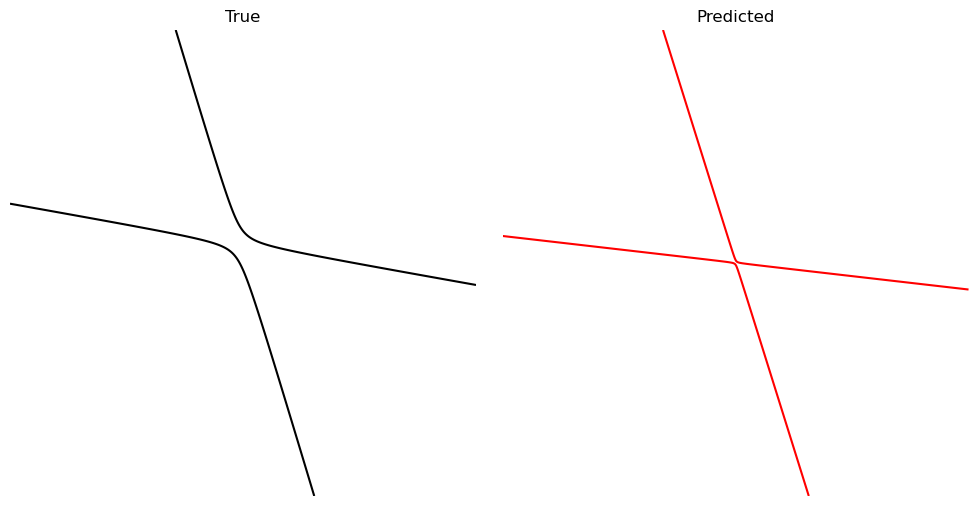

In [53]:
import numpy as np
import matplotlib.pyplot as plt

# --- prediction ---
pred_coeffs, pred_eq = predict_equation(img_path, model)

# --- sign alignment ---
true_coeffs = np.array([a, b, c, d, e, f0])

if np.dot(pred_coeffs, true_coeffs) < 0:
    pred_coeffs = -pred_coeffs

a_p, b_p, c_p, d_p, e_p, f_p = pred_coeffs

# --- evaluation grid ---
x = np.linspace(-10, 10, 400)
y = np.linspace(-10, 10, 400)
X, Y = np.meshgrid(x, y)

Z_true = (
    a * X**2 +
    b * X * Y +
    c * Y**2 +
    d * X +
    e * Y +
    f0
)

Z_pred = (
    a_p * X**2 +
    b_p * X * Y +
    c_p * Y**2 +
    d_p * X +
    e_p * Y +
    f_p
)

# --- visualization ---
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].contour(X, Y, Z_true, levels=[0], colors="black")
axes[0].set_title("True")
axes[0].set_aspect("equal")
axes[0].axis("off")

axes[1].contour(X, Y, Z_pred, levels=[0], colors="red")
axes[1].set_title("Predicted")
axes[1].set_aspect("equal")
axes[1].axis("off")

plt.tight_layout()
plt.show()

In [54]:
import numpy as np
import matplotlib.pyplot as plt
import os

# =====================================================
# Output directories
# =====================================================

test_dir = os.path.join("assets", "random_test_set")
curve_dir = os.path.join(test_dir, "curve_points")

os.makedirs(test_dir, exist_ok=True)
os.makedirs(curve_dir, exist_ok=True)

# =====================================================
# Parameters
# =====================================================

N_TEST_SAMPLES = 100
N_CURVE_POINTS = 256
EPS = 0.02

test_coeffs = []

# =====================================================
# Generate test set
# =====================================================

for i in range(N_TEST_SAMPLES):

    while True:

        # ---------------------------------------------
        # Random quadratic coefficients
        # ---------------------------------------------

        a, b, c = np.random.uniform(-1, 1, 3)
        d, e = np.random.uniform(-2, 2, 2)
        f0 = np.random.uniform(-3, 3)

        if abs(a) + abs(b) + abs(c) < 0.25:
            continue

        # ---------------------------------------------
        # Normalize coefficients
        # ---------------------------------------------

        norm = np.sqrt(
            a*a + b*b + c*c +
            d*d + e*e + f0*f0
        )

        a /= norm
        b /= norm
        c /= norm
        d /= norm
        e /= norm
        f0 /= norm

        # ---------------------------------------------
        # Evaluate on grid
        # ---------------------------------------------

        x = np.linspace(-10, 10, 400)
        y = np.linspace(-10, 10, 400)
        X, Y = np.meshgrid(x, y)

        Z = (
            a * X**2 +
            b * X * Y +
            c * Y**2 +
            d * X +
            e * Y +
            f0
        )

        # Curve must exist in the visible window
        if not (np.any(Z > 0) and np.any(Z < 0)):
            continue

        # ---------------------------------------------
        # Sample curve points
        # ---------------------------------------------

        mask = np.abs(Z) < EPS
        points = np.column_stack((X[mask], Y[mask]))

        if len(points) < N_CURVE_POINTS:
            continue

        idx = np.random.choice(
            len(points),
            N_CURVE_POINTS,
            replace=False
        )

        curve_points = points[idx].astype(np.float32)

        break

    # ---------------------------------------------
    # Save image
    # ---------------------------------------------

    plt.figure(figsize=(3, 3))
    plt.contour(X, Y, Z, levels=[0], colors="black")
    plt.axis("off")
    plt.gca().set_aspect("equal")

    plt.savefig(
        os.path.join(test_dir, f"test_{i}.png"),
        dpi=100,
        bbox_inches="tight",
        pad_inches=0
    )

    plt.close()

    # ---------------------------------------------
    # Save curve points
    # ---------------------------------------------

    np.save(
        os.path.join(curve_dir, f"test_{i}.npy"),
        curve_points
    )

    # ---------------------------------------------
    # Store true coefficients
    # ---------------------------------------------

    test_coeffs.append([a, b, c, d, e, f0])

print("✅ Random test set generated successfully.")

✅ Random test set generated successfully.


In [55]:
import numpy as np
import os

geometric_errors = []

curve_dir = os.path.join(
    "assets",
    "random_test_set",
    "curve_points"
)

EPS = 1e-6

for i in range(100):

    # -----------------------------------------
    # Load image and predict coefficients
    # -----------------------------------------

    img_path = os.path.join(
        test_dir,
        f"test_{i}.png"
    )

    pred_coeffs, _ = predict_equation(
        img_path,
        model
    )

    # -----------------------------------------
    # Load sampled curve points
    # -----------------------------------------

    points = np.load(
        os.path.join(
            curve_dir,
            f"test_{i}.npy"
        )
    )

    x = points[:, 0]
    y = points[:, 1]

    a, b, c, d, e, f = pred_coeffs

    # -----------------------------------------
    # Evaluate predicted implicit polynomial
    # -----------------------------------------

    F = (
        a * x**2 +
        b * x * y +
        c * y**2 +
        d * x +
        e * y +
        f
    )

    # -----------------------------------------
    # Compute analytical gradient
    # -----------------------------------------

    Fx = 2.0 * a * x + b * y + d
    Fy = b * x + 2.0 * c * y + e

    grad_norm = np.sqrt(Fx**2 + Fy**2 + EPS)

    # -----------------------------------------
    # Geometric error
    # -----------------------------------------

    geom_error = np.mean(np.abs(F) / grad_norm)

    geometric_errors.append(geom_error)

print(f"Mean geometric error: {np.mean(geometric_errors):.6f}")
print(f"Max geometric error : {np.max(geometric_errors):.6f}")

Mean geometric error: 1.037320
Max geometric error : 2.758680


In [56]:
# Worst example according to geometric error

idx = np.argmax(geometric_errors)

print("Worst index:", idx)
print(f"Worst geometric error: {geometric_errors[idx]:.6f}")

Worst index: 33
Worst geometric error: 2.758680


Worst index: 33
Geometric error: 2.758680


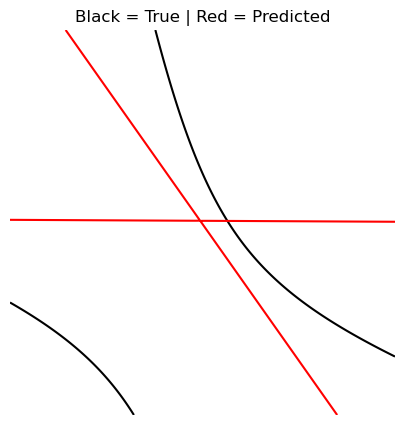

In [57]:
import numpy as np
import matplotlib.pyplot as plt
import os

# Worst example according to geometric error
idx = np.argmax(geometric_errors)

print("Worst index:", idx)
print(f"Geometric error: {geometric_errors[idx]:.6f}")

# True coefficients
true = np.array(test_coeffs[idx])

# Prediction
img_path = os.path.join(test_dir, f"test_{idx}.png")
pred_coeffs, _ = predict_equation(img_path, model)

# Evaluation grid
x = np.linspace(-10, 10, 400)
y = np.linspace(-10, 10, 400)
X, Y = np.meshgrid(x, y)

Z_true = (
    true[0] * X**2 +
    true[1] * X * Y +
    true[2] * Y**2 +
    true[3] * X +
    true[4] * Y +
    true[5]
)

Z_pred = (
    pred_coeffs[0] * X**2 +
    pred_coeffs[1] * X * Y +
    pred_coeffs[2] * Y**2 +
    pred_coeffs[3] * X +
    pred_coeffs[4] * Y +
    pred_coeffs[5]
)

# Plot
plt.figure(figsize=(5, 5))
plt.contour(X, Y, Z_true, levels=[0], colors="black")
plt.contour(X, Y, Z_pred, levels=[0], colors="red")
plt.gca().set_aspect("equal")
plt.axis("off")
plt.title("Black = True | Red = Predicted")
plt.show()

In [58]:
# --- SUCCESS EXAMPLE EXPORT (Best Geometric Prediction) ---

import numpy as np
import matplotlib.pyplot as plt
import os

export_dir = "assets"
os.makedirs(export_dir, exist_ok=True)

# -------------------------------------------------
# Select best example
# -------------------------------------------------

best_idx = np.argmin(geometric_errors)

print("Best index:", best_idx)
print(f"Geometric error: {geometric_errors[best_idx]:.6f}")

# -------------------------------------------------
# Load true coefficients and prediction
# -------------------------------------------------

true = np.array(test_coeffs[best_idx])

img_path = os.path.join(
    test_dir,
    f"test_{best_idx}.png"
)

pred_coeffs, _ = predict_equation(img_path, model)

# Sign alignment (for visualization only)
if np.dot(pred_coeffs, true) < 0:
    pred_coeffs = -pred_coeffs

# -------------------------------------------------
# Evaluation grid
# -------------------------------------------------

x = np.linspace(-10, 10, 400)
y = np.linspace(-10, 10, 400)
X, Y = np.meshgrid(x, y)

Z_true = (
    true[0] * X**2 +
    true[1] * X * Y +
    true[2] * Y**2 +
    true[3] * X +
    true[4] * Y +
    true[5]
)

Z_pred = (
    pred_coeffs[0] * X**2 +
    pred_coeffs[1] * X * Y +
    pred_coeffs[2] * Y**2 +
    pred_coeffs[3] * X +
    pred_coeffs[4] * Y +
    pred_coeffs[5]
)

# -------------------------------------------------
# Save input image
# -------------------------------------------------

plt.figure(figsize=(3, 3))
plt.contour(X, Y, Z_true, levels=[0], colors="black")
plt.axis("off")
plt.gca().set_aspect("equal")

plt.savefig(
    os.path.join(export_dir, "example_success.png"),
    dpi=250,
    bbox_inches="tight",
    pad_inches=0
)

plt.close()

# -------------------------------------------------
# Save overlay
# -------------------------------------------------

plt.figure(figsize=(4, 4))

plt.contour(
    X,
    Y,
    Z_true,
    levels=[0],
    colors="black"
)

plt.contour(
    X,
    Y,
    Z_pred,
    levels=[0],
    colors="red"
)

plt.axis("off")
plt.gca().set_aspect("equal")

plt.savefig(
    os.path.join(
        export_dir,
        "example_success_overlay.png"
    ),
    dpi=250,
    bbox_inches="tight",
    pad_inches=0
)

plt.close()

Best index: 47
Geometric error: 0.502127


Best index: 47
Geometric error: 0.502127


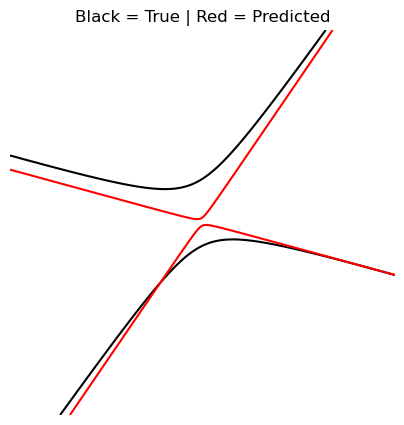

In [59]:
import numpy as np
import matplotlib.pyplot as plt
import os

# Best example according to geometric error
idx = np.argmin(geometric_errors)

print("Best index:", idx)
print(f"Geometric error: {geometric_errors[idx]:.6f}")

# True coefficients
true = np.array(test_coeffs[idx])

# Prediction
img_path = os.path.join(test_dir, f"test_{idx}.png")
pred_coeffs, _ = predict_equation(img_path, model)

# Sign alignment (for visualization only)
if np.dot(pred_coeffs, true) < 0:
    pred_coeffs = -pred_coeffs

# Evaluation grid
x = np.linspace(-10, 10, 400)
y = np.linspace(-10, 10, 400)
X, Y = np.meshgrid(x, y)

Z_true = (
    true[0] * X**2 +
    true[1] * X * Y +
    true[2] * Y**2 +
    true[3] * X +
    true[4] * Y +
    true[5]
)

Z_pred = (
    pred_coeffs[0] * X**2 +
    pred_coeffs[1] * X * Y +
    pred_coeffs[2] * Y**2 +
    pred_coeffs[3] * X +
    pred_coeffs[4] * Y +
    pred_coeffs[5]
)

# Plot
plt.figure(figsize=(5, 5))
plt.contour(X, Y, Z_true, levels=[0], colors="black")
plt.contour(X, Y, Z_pred, levels=[0], colors="red")
plt.gca().set_aspect("equal")
plt.axis("off")
plt.title("Black = True | Red = Predicted")
plt.show()